# Assess handscan grid inference (multi-metric)

ROC / score analysis for **curated** handscan campaigns
(`handscan_curated_ddim2ddim_T100-200_*` @ ckpt 34000). Compares **all AD metrics**:
`mse`, `weighted_mse`, `noise_region_mse`, `latent_l2`, `denoise_loss`,
`posterior_typicality` (when jobs were submitted with `--ad-posterior-k > 0`),
plus **calibrated** `noise_region_mse` z-scored on healthy.

Prefers `*_ad_metrics.npz` from grid jobs; falls back to recomputing pixel metrics
from `*_arrays.npz` for older campaigns.

**Kernel:** `env`


In [27]:
from __future__ import annotations

import json
import pickle
import re
import tarfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import auc, roc_curve

APP_ROOT = Path("/exp/sbnd/app/users/munjung/anomaly-detection")
import sys
sys.path.insert(0, str(APP_ROOT))
from configs.paths import DATA_ROOT
sys.path.insert(0, str(APP_ROOT / "inference"))
from ad_metrics import (  # noqa: E402
    METRIC_NAMES,
    calibrate_scores,
    compute_pixel_metrics_from_arrays_npz,
    file_score_from_patch_scores,
    load_ad_metrics_npz,
    pixel_metric_maps,
)

PNFS_OUT = Path("/pnfs/sbnd/scratch/users/munjung/anomaly-detection/out/inference")
CURATED = DATA_ROOT / "samples" / "handscan" / "curated"
MANIFEST_DIR = CURATED / "manifests"
UNPACK_ROOT = DATA_ROOT / "inference" / "grid_unpacked" / "handscan_curated_ddim2ddim_T100-200"
FIG_DIR = DATA_ROOT / "figures" / "handscan_curated_ddim2ddim_T100-200"
ROC_DIR = DATA_ROOT / "roc_curves" / "handscan_curated_ddim2ddim_T100-200"
FIG_DIR.mkdir(parents=True, exist_ok=True)
ROC_DIR.mkdir(parents=True, exist_ok=True)

# --- Curated handscan: ddim2ddim only, T=100/200, ckpt 34000 ---
CAMPAIGNS = {
    "linear": PNFS_OUT
    / "2026_09_16_172443__handscan_curated_ddim2ddim_T100-200_linear_ckpt034000_T100-200_ddim2ddim",
    "anisotropic": PNFS_OUT
    / "2026_09_16_172534__handscan_curated_ddim2ddim_T100-200_anisotropic_ckpt034000_T100-200_ddim2ddim",
}

T_VALUES = [100, 200]
MODES = ["ddim2ddim"]
METRICS = list(METRIC_NAMES)  # plus calibrated_noise_region_mse after collection
FILE_REDUCTION = "max"  # max | mean | p95 over patches
ROC_LABEL = "SBND_handscan_curated_ddim2ddim"
EXPECTED_JOBS = 182

plt.rcParams["figure.dpi"] = 110
for name, path in CAMPAIGNS.items():
    n_tgz = len(list(path.glob("out_*.tgz"))) if path.is_dir() else 0
    n_log = len(list(path.glob("log_*.log"))) if path.is_dir() else 0
    print(f"{name:12s} exists={path.is_dir()}  out_tgz={n_tgz:3d}/{EXPECTED_JOBS}  logs={n_log:3d}")
    print(f"             {path.name}")


linear       exists=True  out_tgz=182/182  logs=182
             2026_09_16_172443__handscan_curated_ddim2ddim_T100-200_linear_ckpt034000_T100-200_ddim2ddim
anisotropic  exists=True  out_tgz=182/182  logs=182
             2026_09_16_172534__handscan_curated_ddim2ddim_T100-200_anisotropic_ckpt034000_T100-200_ddim2ddim


## Label lookup from preparation manifests

In [28]:
def load_jsonl(path: Path) -> list[dict]:
    rows = []
    if not path.is_file():
        return rows
    with path.open() as fh:
        for line in fh:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def stem_from_sample_id(sample_id: str) -> str:
    return re.sub(r"[^A-Za-z0-9._-]+", "_", sample_id)


# Curated manifests use healthy / unhealthy (/ unique). Map unhealthy → diseased
# so the ROC cells (healthy vs diseased) work unchanged.
_LABEL_MAP = {
    "healthy": "healthy",
    "unhealthy": "diseased",
    "diseased": "diseased",
    "outlier": "outlier",
    "unique": "unique",
}

label_by_stem: dict[str, str] = {}
note_by_stem: dict[str, str] = {}
for split_file, default_label in (
    ("healthy", "healthy"),
    ("unhealthy", "diseased"),
    ("diseased", "diseased"),
    ("outlier", "outlier"),
    ("unique", "unique"),
):
    for row in load_jsonl(MANIFEST_DIR / f"{split_file}.jsonl"):
        stem = (
            Path(row["npz_name"]).stem
            if row.get("npz_name")
            else (row.get("stem") or stem_from_sample_id(row["sample_id"]))
        )
        raw = row.get("label", default_label)
        label_by_stem[stem] = _LABEL_MAP.get(raw, default_label)
        note_by_stem[stem] = row.get("note", "")

print(f"labeled stems: {len(label_by_stem)}")
print(pd.Series(label_by_stem).value_counts().to_string())


labeled stems: 182
healthy     96
diseased    79
unique       7


## Unpack grid tarballs (once per campaign)

Expect **182** `out_*.tgz` per curated campaign (one NPZ per job). Re-run this cell as jobs finish.


In [29]:
EXPECTED_JOBS = 182


def unpack_campaign(campaign_dir: Path, dest: Path) -> int:
    dest.mkdir(parents=True, exist_ok=True)
    n = 0
    for tgz in sorted(campaign_dir.glob("out_*.tgz")):
        job = tgz.stem.split("_")[1]
        job_dir = dest / f"job_{job}"
        marker = job_dir / ".unpack_ok"
        if marker.is_file():
            n += 1
            continue
        job_dir.mkdir(parents=True, exist_ok=True)
        with tarfile.open(tgz, "r:gz") as tf:
            tf.extractall(job_dir)
        marker.write_text(tgz.name + "\n")
        n += 1
    return n


for cfg, camp in CAMPAIGNS.items():
    if not camp.is_dir():
        print(f"[skip] missing {cfg}: {camp}")
        continue
    dest = UNPACK_ROOT / cfg
    done = unpack_campaign(camp, dest)
    n_tgz = len(list(camp.glob("out_*.tgz")))
    n_log = len(list(camp.glob("log_*.log")))
    pending = max(0, EXPECTED_JOBS - n_tgz)
    print(f"{cfg}: unpacked {done}/{EXPECTED_JOBS} → {dest}")
    print(f"  pnfs: out_tgz={n_tgz}  logs={n_log}  still_missing≈{pending}")
    if pending:
        print("  (re-run this cell after more jobs finish)")


linear: unpacked 182/182 → /exp/sbnd/data/users/munjung/anomaly-detection/inference/grid_unpacked/handscan_curated_ddim2ddim_T100-200/linear
  pnfs: out_tgz=182  logs=182  still_missing≈0
anisotropic: unpacked 182/182 → /exp/sbnd/data/users/munjung/anomaly-detection/inference/grid_unpacked/handscan_curated_ddim2ddim_T100-200/anisotropic
  pnfs: out_tgz=182  logs=182  still_missing≈0


## Collect scores from unpacked outputs

Uses `*_ad_metrics.npz` when available; otherwise recomputes pixel metrics from arrays.


In [30]:
def find_arrays(unpacked_root: Path, stem: str, T: int, mode: str) -> Path | None:
    pats = [
        f"**/{stem}_T{T}_{mode}_arrays.npz",
    ]
    if mode != "ddim2ddim":
        pats.append(f"**/mixed_{mode}/{stem}_T{T}_{mode}_arrays.npz")
    for pat in pats:
        hits = list(unpacked_root.glob(pat))
        if hits:
            return hits[0]
    return None


def find_ad_metrics(unpacked_root: Path, stem: str, T: int, mode: str) -> Path | None:
    pats = [f"**/{stem}_T{T}_{mode}_ad_metrics.npz"]
    if mode != "ddim2ddim":
        pats.append(f"**/mixed_{mode}/{stem}_T{T}_{mode}_ad_metrics.npz")
    for pat in pats:
        hits = list(unpacked_root.glob(pat))
        if hits:
            return hits[0]
    return None


def patch_scores_for_file(unpacked_root: Path, stem: str, T: int, mode: str) -> dict[str, np.ndarray]:
    mpath = find_ad_metrics(unpacked_root, stem, T, mode)
    if mpath is not None:
        z = load_ad_metrics_npz(mpath)
        out = {}
        for name in METRIC_NAMES:
            if name in z:
                out[name] = np.asarray(z[name], dtype=np.float64)
        return out
    apath = find_arrays(unpacked_root, stem, T, mode)
    if apath is None:
        return {}
    # legacy: RMS of saliency ≈ sqrt(mse) up to channel layout — keep mse family
    pix = compute_pixel_metrics_from_arrays_npz(apath)
    z = np.load(apath, allow_pickle=True)
    sal = z["saliency"].astype(np.float64)
    rms = [float(np.sqrt(np.mean(sal[i] ** 2))) for i in range(len(sal))]
    pix = {k: np.asarray(v, dtype=np.float64) for k, v in pix.items()}
    pix["saliency_rms"] = np.asarray(rms, dtype=np.float64)
    return pix


def collect_scores(cfg: str, T: int, mode: str) -> pd.DataFrame:
    dest = UNPACK_ROOT / cfg
    rows = []
    for stem, label in label_by_stem.items():
        patch = patch_scores_for_file(dest, stem, T, mode)
        if not patch:
            continue
        for metric, arr in patch.items():
            score = file_score_from_patch_scores(arr, FILE_REDUCTION)
            rows.append(
                {
                    "config": cfg,
                    "T": T,
                    "mode": mode,
                    "stem": stem,
                    "label": label,
                    "metric": metric,
                    "score": score,
                    "n_patches": int(np.asarray(arr).size),
                }
            )
    return pd.DataFrame(rows)


frames = []
for cfg in CAMPAIGNS:
    for T in T_VALUES:
        for mode in MODES:
            df = collect_scores(cfg, T, mode)
            if not df.empty:
                frames.append(df)
                print(f"{cfg} T={T} {mode}: {len(df)} rows, metrics={sorted(df['metric'].unique())}")

scores_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
print(f"\nscore rows: {len(scores_df)}")

# Calibrated residual: z-score noise_region_mse using healthy null (per config,T,mode)
cal_rows = []
if not scores_df.empty and "noise_region_mse" in set(scores_df["metric"]):
    for (cfg, T, mode), grp in scores_df[scores_df["metric"] == "noise_region_mse"].groupby(
        ["config", "T", "mode"]
    ):
        healthy = grp.loc[grp["label"] == "healthy", "score"].to_numpy()
        for _, row in grp.iterrows():
            cal_rows.append(
                {
                    "config": cfg,
                    "T": T,
                    "mode": mode,
                    "stem": row["stem"],
                    "label": row["label"],
                    "metric": "calibrated_noise_region_mse",
                    "score": float(calibrate_scores(np.array([row["score"]]), healthy)[0]),
                    "n_patches": row["n_patches"],
                }
            )
    if cal_rows:
        scores_df = pd.concat([scores_df, pd.DataFrame(cal_rows)], ignore_index=True)

if not scores_df.empty:
    display(scores_df.groupby(["config", "T", "metric", "label"]).size().unstack(fill_value=0))
else:
    print("No scores yet — unpack finished jobs first, then re-run.")


linear T=100 ddim2ddim: 728 rows, metrics=['mse', 'noise_region_mse', 'saliency_rms', 'weighted_mse']
linear T=200 ddim2ddim: 728 rows, metrics=['mse', 'noise_region_mse', 'saliency_rms', 'weighted_mse']
anisotropic T=100 ddim2ddim: 728 rows, metrics=['mse', 'noise_region_mse', 'saliency_rms', 'weighted_mse']
anisotropic T=200 ddim2ddim: 728 rows, metrics=['mse', 'noise_region_mse', 'saliency_rms', 'weighted_mse']

score rows: 2912


label                                        diseased  healthy  unique
config      T   metric                                                
anisotropic 100 calibrated_noise_region_mse        79       96       7
                mse                                79       96       7
                noise_region_mse                   79       96       7
                saliency_rms                       79       96       7
                weighted_mse                       79       96       7
            200 calibrated_noise_region_mse        79       96       7
                mse                                79       96       7
                noise_region_mse                   79       96       7
                saliency_rms                       79       96       7
                weighted_mse                       79       96       7
linear      100 calibrated_noise_region_mse        79       96       7
                mse                                79       96       7
                noise_region_mse                   79       96       7
                saliency_rms                       79       96       7
                weighted_mse                       79       96       7
            200 calibrated_noise_region_mse        79       96       7
                mse                                79       96       7
                noise_region_mse                   79       96       7
                saliency_rms                       79       96       7
                weighted_mse                       79       96       7

## ROC: healthy vs diseased (per metric / config / T)

One ROC per AD metric. Higher score = more anomalous.


In [31]:
def roc_for_subset(df: pd.DataFrame) -> dict | None:
    sub = df[df["label"].isin(["healthy", "diseased"])].dropna(subset=["score"])
    if sub["label"].nunique() < 2:
        return None
    y = (sub["label"] == "diseased").astype(int).to_numpy()
    s = sub["score"].to_numpy()
    if not np.isfinite(s).all():
        mask = np.isfinite(s)
        y, s = y[mask], s[mask]
    if len(np.unique(y)) < 2:
        return None
    fpr, tpr, thr = roc_curve(y, s)
    return {"fpr": fpr, "tpr": tpr, "thr": thr, "auc": float(auc(fpr, tpr)), "n": int(len(y))}


roc_rows = []
if not scores_df.empty:
    for (cfg, T, mode, metric), grp in scores_df.groupby(["config", "T", "mode", "metric"]):
        r = roc_for_subset(grp)
        if r is None:
            continue
        roc_rows.append(
            {"config": cfg, "T": T, "mode": mode, "metric": metric, "auc": r["auc"], "n": r["n"], **{k: r[k] for k in ("fpr", "tpr", "thr")}}
        )

roc_table = pd.DataFrame(
    [{k: v for k, v in row.items() if k not in ("fpr", "tpr", "thr")} for row in roc_rows]
) if roc_rows else pd.DataFrame()
roc_curves = {(r["config"], r["T"], r["mode"], r["metric"]): r for r in roc_rows}

if not roc_table.empty:
    display(roc_table.sort_values(["metric", "config", "T"]).reset_index(drop=True))
else:
    print("No ROC yet (need both healthy and diseased scores).")


,config,T,mode,metric,auc,n
0,anisotropic,100,ddim2ddim,calibrated_noise_region_mse,0.338608,175
1,anisotropic,200,ddim2ddim,calibrated_noise_region_mse,0.325290,175
2,linear,100,ddim2ddim,calibrated_noise_region_mse,0.661788,175
3,linear,200,ddim2ddim,calibrated_noise_region_mse,0.661392,175
4,anisotropic,100,ddim2ddim,mse,0.315137,175
5,anisotropic,200,ddim2ddim,mse,0.311313,175
6,linear,100,ddim2ddim,mse,0.379879,175
7,linear,200,ddim2ddim,mse,0.371572,175
8,anisotropic,100,ddim2ddim,noise_region_mse,0.338608,175
9,anisotropic,200,ddim2ddim,noise_region_mse,0.325290,175


wrote /exp/sbnd/data/users/munjung/anomaly-detection/figures/handscan_curated_ddim2ddim_T100-200/roc_by_metric.png


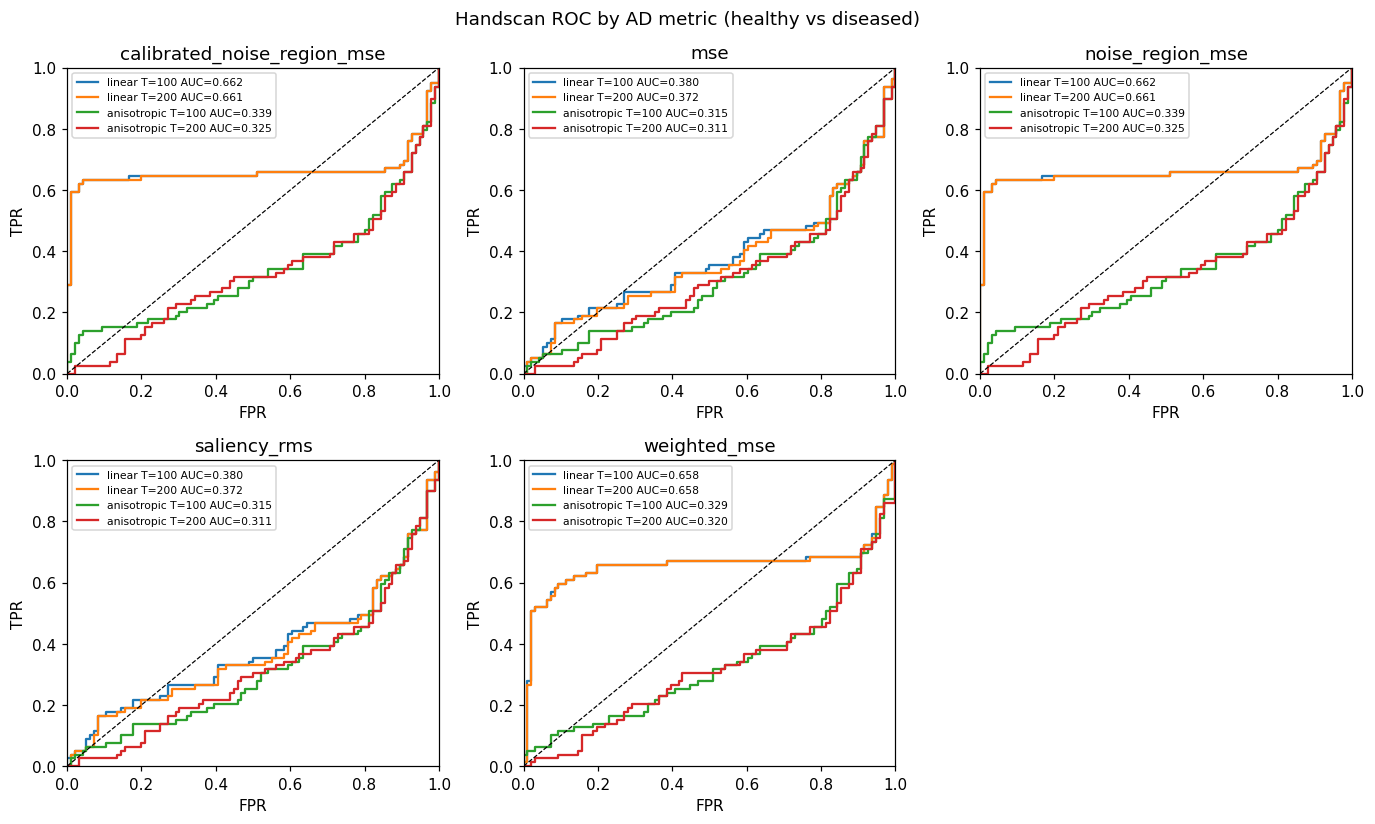

config                      anisotropic        linear       
T                                   100    200    100    200
metric                                                      
calibrated_noise_region_mse       0.339  0.325  0.662  0.661
mse                               0.315  0.311  0.380  0.372
noise_region_mse                  0.339  0.325  0.662  0.661
saliency_rms                      0.315  0.311  0.380  0.372
weighted_mse                      0.329  0.320  0.658  0.658

In [32]:
if not roc_table.empty:
    metrics = list(dict.fromkeys(roc_table["metric"].tolist()))
    n = len(metrics)
    ncols = min(3, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.8 * nrows), squeeze=False)
    for ax, metric in zip(axes.ravel(), metrics):
        for cfg in CAMPAIGNS:
            for T in T_VALUES:
                key = (cfg, T, "ddim2ddim", metric)
                # mode may vary
                matches = [k for k in roc_curves if k[0] == cfg and k[1] == T and k[3] == metric]
                if not matches:
                    continue
                r = roc_curves[matches[0]]
                ax.plot(r["fpr"], r["tpr"], label=f"{cfg} T={T} AUC={r['auc']:.3f}")
        ax.plot([0, 1], [0, 1], "k--", lw=0.8)
        ax.set_title(metric)
        ax.set_xlabel("FPR")
        ax.set_ylabel("TPR")
        ax.legend(fontsize=7)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
    for ax in axes.ravel()[n:]:
        ax.axis("off")
    fig.suptitle("Handscan ROC by AD metric (healthy vs diseased)")
    fig.tight_layout()
    out = FIG_DIR / "roc_by_metric.png"
    fig.savefig(out, dpi=140)
    print("wrote", out)
    plt.show()

    # AUC heatmap-style table
    pivot = roc_table.pivot_table(index="metric", columns=["config", "T"], values="auc")
    display(pivot.round(3))
else:
    print("No ROC curves to plot.")


## Best ROC — drop unphysical diseased patches

`linear` + `calibrated_noise_region_mse` rises sharply to TPR≈0.63 at FPR≲0.05, then a long
plateau and a late upward tick. Handscan of the late/hard positives shows those tiles are
**unphysical for this label** (track-dominated patches without the streak / coherent-noise
signature the metric is meant to catch).

Below: drop diseased stems scoring below the end-of-rise threshold, then plot that single curve.


In [33]:
# --- Best single ROC after dropping unphysical late diseased ---
BEST_CFG = "linear"
BEST_T = 100
BEST_MODE = "ddim2ddim"
BEST_METRIC = "calibrated_noise_region_mse"
# Operating point that ends the sharp rise / starts the plateau (FPR cap).
PLATEAU_FPR_CAP = 0.05

sub = scores_df[
    (scores_df["config"] == BEST_CFG)
    & (scores_df["T"] == BEST_T)
    & (scores_df["mode"] == BEST_MODE)
    & (scores_df["metric"] == BEST_METRIC)
    & (scores_df["label"].isin(["healthy", "diseased"]))
].copy()
if sub.empty:
    raise RuntimeError("No scores for best ROC selection — run collect + ROC cells first.")

y = (sub["label"] == "diseased").astype(int).to_numpy()
s = sub["score"].to_numpy(dtype=float)
fpr, tpr, thr = roc_curve(y, s)

# End-of-rise = max TPR among finite thresholds with FPR <= PLATEAU_FPR_CAP
# sklearn thr length is len(fpr) - 1
fpr_t, tpr_t = fpr[:-1], tpr[:-1]
assert len(fpr_t) == len(thr)
finite = np.isfinite(thr)
mask = (fpr_t <= PLATEAU_FPR_CAP) & finite
if not mask.any():
    mask = fpr_t <= PLATEAU_FPR_CAP
i_rise = int(np.argmax(np.where(mask, tpr_t, -np.inf)))
rise_thr = float(thr[i_rise])
rise_tpr, rise_fpr = float(tpr_t[i_rise]), float(fpr_t[i_rise])
print(
    f"End-of-rise threshold: {rise_thr:.6g}  "
    f"(TPR={rise_tpr:.3f}, FPR={rise_fpr:.3f} @ FPR≤{PLATEAU_FPR_CAP})"
)

# Diseased below this threshold drive the plateau + upward tick → drop
hard = sub[(sub["label"] == "diseased") & (sub["score"] < rise_thr)]
DROP_UNPHYSICAL_STEMS = sorted(hard["stem"].unique().tolist())
n_dis = int((sub["label"] == "diseased").sum())
print(
    f"Dropping {len(DROP_UNPHYSICAL_STEMS)} unphysical diseased stems "
    f"(of {n_dis} diseased):"
)
for stem in DROP_UNPHYSICAL_STEMS:
    note = note_by_stem.get(stem, "")
    sc = float(hard.loc[hard["stem"] == stem, "score"].iloc[0])
    print(f"  {sc:8.3f}  {stem}  | {note}")

drop_path = ROC_DIR / f"drop_unphysical_{BEST_CFG}_T{BEST_T}_{BEST_METRIC}.json"
drop_path.write_text(
    json.dumps(
        {
            "config": BEST_CFG,
            "T": BEST_T,
            "mode": BEST_MODE,
            "metric": BEST_METRIC,
            "rise_thr": rise_thr,
            "rise_tpr": rise_tpr,
            "rise_fpr": rise_fpr,
            "stems": DROP_UNPHYSICAL_STEMS,
        },
        indent=2,
    )
)
print("wrote", drop_path)

kept = sub[~sub["stem"].isin(DROP_UNPHYSICAL_STEMS)]
r_kept = roc_for_subset(kept)
assert r_kept is not None

fig, ax = plt.subplots(figsize=(5.0, 5.0))
ax.plot(r_kept["fpr"], r_kept["tpr"], color="C0", lw=2.4,
        label=f"AUC={r_kept['auc']:.3f}  n={r_kept['n']}")
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_title(
    f"{BEST_CFG} T={BEST_T} {BEST_METRIC}\n"
    f"(dropped {len(DROP_UNPHYSICAL_STEMS)} unphysical diseased)"
)
ax.legend(fontsize=9, loc="lower right")
fig.tight_layout()
out = FIG_DIR / f"roc_best_{BEST_CFG}_T{BEST_T}_{BEST_METRIC}_drop_unphysical.png"
fig.savefig(out, dpi=140)
print("wrote", out)
plt.show()

out_json = ROC_DIR / f"{BEST_CFG}_best_{BEST_METRIC}_T{BEST_T}_drop_unphysical.json"
out_json.write_text(
    json.dumps(
        {
            "label": ROC_LABEL + "_drop_unphysical",
            "config": BEST_CFG,
            "T": BEST_T,
            "mode": BEST_MODE,
            "metric": BEST_METRIC,
            "auc": r_kept["auc"],
            "n": r_kept["n"],
            "n_dropped_diseased": len(DROP_UNPHYSICAL_STEMS),
            "dropped_stems": DROP_UNPHYSICAL_STEMS,
            "fpr": r_kept["fpr"].tolist(),
            "tpr": r_kept["tpr"].tolist(),
        },
        indent=2,
    )
)
print("wrote", out_json)


AssertionError: 

## Anomaly metric maps — successfully classified cases

Show **all** patches that the Youden threshold on the chosen file-level metric
classifies correctly:

- **TP**: diseased / score ≥ thr  
- **TN**: healthy / score < thr  

Each figure: original, pixel anomaly map, threshold highlight, binary mask.


In [ ]:
# --- Spatial anomaly maps for ALL correctly classified files ---
VIZ_CFG = "anisotropic"  # or "linear"
VIZ_T = 200
VIZ_MODE = "ddim2ddim"
# Pixel map: "weighted_sq_err" | "sq_err" | "abs_residual"
MAP_KIND = "weighted_sq_err"
SCALAR_METRIC = {
    "weighted_sq_err": "weighted_mse",
    "sq_err": "mse",
    "abs_residual": "mse",
}.get(MAP_KIND, "weighted_mse")

HEALTHY_QUANTILE = 0.99  # pixel highlight threshold from healthy null
ABS_QUANTILE_MASK = 0.70
PATCH_INDEX = 0
# Set to an int to cap plots (e.g. 20); None = show every TP/TN
MAX_SHOW = None
SAVE_PDF = True

dest = UNPACK_ROOT / VIZ_CFG
if not dest.is_dir():
    raise FileNotFoundError(f"Unpack {VIZ_CFG} first: {dest}")

key = (VIZ_CFG, VIZ_T, VIZ_MODE, SCALAR_METRIC)
if "roc_curves" not in globals() or key not in roc_curves:
    raise RuntimeError(
        f"Need ROC for {key}. Run the score-collection + ROC cells first."
    )
if "scores_df" not in globals() or scores_df.empty:
    raise RuntimeError("Need scores_df — run the collect-scores cell first.")

r = roc_curves[key]
fpr, tpr, thr = np.asarray(r["fpr"]), np.asarray(r["tpr"]), np.asarray(r["thr"], dtype=float)
j = tpr - fpr
# sklearn puts +inf at thr[0] (score > all); skip non-finite thresholds for Youden
finite = np.isfinite(thr)
if not finite.any():
    # Fall back: midpoint between sorted unique scores from scores_df
    sub = scores_df[
        (scores_df["config"] == VIZ_CFG)
        & (scores_df["T"] == VIZ_T)
        & (scores_df["mode"] == VIZ_MODE)
        & (scores_df["metric"] == SCALAR_METRIC)
        & (scores_df["label"].isin(["healthy", "diseased"]))
    ]
    y = (sub["label"] == "diseased").astype(int).to_numpy()
    s = sub["score"].to_numpy(dtype=float)
    order = np.argsort(-s)
    y_s, s_s = y[order], s[order]
    tps = np.cumsum(y_s)
    fps = np.cumsum(1 - y_s)
    n_pos, n_neg = float(tps[-1]), float(fps[-1])
    tpr_f = tps / max(n_pos, 1.0)
    fpr_f = fps / max(n_neg, 1.0)
    j_f = tpr_f - fpr_f
    i = int(np.nanargmax(j_f))
    # threshold = score at chosen rank (predict anomalous if score >= thr)
    youden_thr = float(s_s[i])
    tpr_i, fpr_i = float(tpr_f[i]), float(fpr_f[i])
else:
    j_masked = np.where(finite, j, -np.inf)
    i = int(np.argmax(j_masked))
    youden_thr = float(thr[i])
    tpr_i, fpr_i = float(tpr[i]), float(fpr[i])
    # If still non-finite, step to nearest finite neighbor
    if not np.isfinite(youden_thr):
        finite_idx = np.flatnonzero(finite)
        # pick finite thr with best J among finite points
        i = int(finite_idx[np.argmax(j[finite_idx])])
        youden_thr = float(thr[i])
        tpr_i, fpr_i = float(tpr[i]), float(fpr[i])

if not np.isfinite(youden_thr):
    raise RuntimeError("Could not get a finite Youden threshold from ROC.")
print(
    f"Youden thr on file {SCALAR_METRIC}: {youden_thr:.6g}  "
    f"(AUC={r['auc']:.3f}, TPR={tpr_i:.3f}, FPR={fpr_i:.3f})"
)


def _load_orig_reco(stem: str):
    ap = find_arrays(dest, stem, VIZ_T, VIZ_MODE)
    if ap is None:
        return None
    z = np.load(ap)
    orig = np.asarray(z["original"], dtype=np.float32)
    reco = np.asarray(z["reconstructed"], dtype=np.float32)
    sal = (
        np.asarray(z["saliency"], dtype=np.float32)
        if "saliency" in z.files
        else reco - orig
    )
    return orig, reco, sal, ap


def _hw(a: np.ndarray, idx: int = PATCH_INDEX) -> np.ndarray:
    a = np.asarray(a)
    if a.ndim == 4:
        return np.squeeze(a[idx])
    if a.ndim == 3:
        return np.squeeze(a[idx] if a.shape[0] <= 8 else a)
    return np.squeeze(a)


def pixel_anomaly_map(orig, reco, sal) -> np.ndarray:
    o = _hw(orig)
    r = _hw(reco)
    s = _hw(sal)
    if MAP_KIND == "abs_residual":
        return np.abs(s if s is not None else (r - o)).astype(np.float64)
    maps = pixel_metric_maps(
        o[None, None], r[None, None], abs_quantile=ABS_QUANTILE_MASK
    )
    return np.squeeze(maps[MAP_KIND]).astype(np.float64)


def file_scalar(stem: str) -> float | None:
    sub = scores_df[
        (scores_df["config"] == VIZ_CFG)
        & (scores_df["T"] == VIZ_T)
        & (scores_df["mode"] == VIZ_MODE)
        & (scores_df["metric"] == SCALAR_METRIC)
        & (scores_df["stem"] == stem)
    ]
    if sub.empty:
        return None
    return float(sub["score"].iloc[0])


# Pixel threshold from healthy null (for spatial highlight only)
healthy_stems = [s for s, lab in label_by_stem.items() if lab == "healthy"]
diseased_stems = [s for s, lab in label_by_stem.items() if lab == "diseased"]
healthy_pix = []
for stem in healthy_stems:
    loaded = _load_orig_reco(stem)
    if loaded is None:
        continue
    orig, reco, sal, _ = loaded
    healthy_pix.append(pixel_anomaly_map(orig, reco, sal).ravel())
if not healthy_pix:
    raise RuntimeError("No healthy arrays found.")
pix_thr = float(np.quantile(np.concatenate(healthy_pix), HEALTHY_QUANTILE))
print(f"pixel thr ({MAP_KIND}, healthy q={HEALTHY_QUANTILE}): {pix_thr:.6g}")

# Classify every stem with arrays + score
rows = []
for lab, pool in (("diseased", diseased_stems), ("healthy", healthy_stems)):
    for stem in pool:
        if find_arrays(dest, stem, VIZ_T, VIZ_MODE) is None:
            continue
        sc = file_scalar(stem)
        if sc is None or not np.isfinite(sc):
            continue
        pred_anom = sc >= youden_thr
        true_anom = lab == "diseased"
        correct = pred_anom == true_anom
        kind = (
            "TP" if (true_anom and pred_anom)
            else "TN" if ((not true_anom) and (not pred_anom))
            else "FP" if ((not true_anom) and pred_anom)
            else "FN"
        )
        rows.append(
            {
                "stem": stem,
                "label": lab,
                "score": sc,
                "pred_anom": pred_anom,
                "correct": correct,
                "kind": kind,
            }
        )

cls_df = pd.DataFrame(rows)
print("\nclassification counts:")
print(cls_df["kind"].value_counts().to_string())
n_ok = int(cls_df["correct"].sum())
n_tot = len(cls_df)
print(f"accuracy: {n_ok}/{n_tot} = {n_ok / max(n_tot, 1):.3f}")

# Successfully classified = TP + TN, sorted by score (TP high→low, TN low→high)
ok = cls_df[cls_df["correct"]].copy()
tp = ok[ok["kind"] == "TP"].sort_values("score", ascending=False)
tn = ok[ok["kind"] == "TN"].sort_values("score", ascending=True)
show_df = pd.concat([tp, tn], ignore_index=True)
if MAX_SHOW is not None:
    show_df = show_df.head(int(MAX_SHOW))
    print(f"\nShowing {len(show_df)}/{n_ok} correct cases (MAX_SHOW={MAX_SHOW})")
else:
    print(f"\nShowing all {len(show_df)} correctly classified cases")


def plot_anomaly_overlay(stem: str, label: str, kind: str, score: float) -> None:
    loaded = _load_orig_reco(stem)
    if loaded is None:
        print(f"missing arrays: {stem}")
        return
    orig, reco, sal, _ = loaded
    o = _hw(orig)
    amap = pixel_anomaly_map(orig, reco, sal)
    flag = amap > pix_thr

    fig, axes = plt.subplots(1, 4, figsize=(14, 3.4))
    axes[0].imshow(o, aspect="auto", origin="lower", cmap="viridis", vmin=-1, vmax=1)
    axes[0].set_title("original")
    im1 = axes[1].imshow(amap, aspect="auto", origin="lower", cmap="magma")
    axes[1].set_title(MAP_KIND)
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    axes[2].imshow(o, aspect="auto", origin="lower", cmap="viridis", vmin=-1, vmax=1)
    overlay = np.zeros((*flag.shape, 4), dtype=float)
    overlay[..., 0] = 1.0
    overlay[..., 3] = np.where(flag, 0.45, 0.0)
    axes[2].imshow(overlay, aspect="auto", origin="lower")
    if flag.any():
        axes[2].contour(flag.astype(float), levels=[0.5], colors=["cyan"], linewidths=0.8)
    axes[2].set_title(f"highlight > q{HEALTHY_QUANTILE:.2f}\nfrac={flag.mean():.3f}")

    axes[3].imshow(flag, aspect="auto", origin="lower", cmap="gray")
    axes[3].set_title("binary flag mask")
    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle(
        f"{kind} | {label} | {stem}\n"
        f"file {SCALAR_METRIC}={score:.4g}  Youden thr={youden_thr:.4g}",
        fontsize=10,
        y=1.08,
    )
    fig.tight_layout()
    if SAVE_PDF:
        out = FIG_DIR / f"anomap_ok_{VIZ_CFG}_T{VIZ_T}_{kind}_{stem[:50]}.pdf"
        fig.savefig(out, bbox_inches="tight")
    plt.show()
    plt.close(fig)


for _, row in show_df.iterrows():
    plot_anomaly_overlay(row["stem"], row["label"], row["kind"], float(row["score"]))


## Outlier scores vs healthy / diseased distribution

Pick a metric below; compare label classes.


In [ ]:
PLOT_METRIC = "weighted_mse"  # change to any metric in scores_df
PLOT_T = T_VALUES[-1]

if scores_df.empty:
    print("No scores yet.")
else:
    if PLOT_METRIC not in set(scores_df["metric"]):
        PLOT_METRIC = scores_df["metric"].iloc[0]
        print("fallback metric", PLOT_METRIC)
    sub = scores_df[(scores_df["metric"] == PLOT_METRIC) & (scores_df["T"] == PLOT_T)]
    fig, axes = plt.subplots(1, len(CAMPAIGNS), figsize=(5 * len(CAMPAIGNS), 3.5), squeeze=False)
    for ax, cfg in zip(axes[0], CAMPAIGNS):
        g = sub[sub["config"] == cfg]
        for lab, color in [("healthy", "C0"), ("diseased", "C3"), ("outlier", "C2"), ("unique", "C2")]:
            vals = g.loc[g["label"] == lab, "score"].to_numpy()
            vals = vals[np.isfinite(vals)]
            if vals.size:
                ax.hist(vals, bins=15, alpha=0.55, label=f"{lab} n={vals.size}", color=color)
        ax.set_title(f"{cfg}  T={PLOT_T}  {PLOT_METRIC}")
        ax.set_xlabel("file score")
        ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


## Save ROC JSON for best metric per config


In [ ]:
if not roc_table.empty:
    for cfg in roc_table["config"].unique():
        sub = roc_table[roc_table["config"] == cfg].sort_values("auc", ascending=False)
        best = sub.iloc[0]
        key = (best["config"], int(best["T"]), best["mode"], best["metric"])
        r = roc_curves[key]
        payload = {
            "label": ROC_LABEL,
            "config": cfg,
            "T": int(best["T"]),
            "mode": best["mode"],
            "metric": best["metric"],
            "auc": float(best["auc"]),
            "fpr": r["fpr"].tolist(),
            "tpr": r["tpr"].tolist(),
        }
        out = ROC_DIR / f"{cfg}_best_{best['metric']}_T{int(best['T'])}.json"
        out.write_text(json.dumps(payload, indent=2))
        print("wrote", out, f"AUC={best['auc']:.3f}")
else:
    print("nothing to save")
